In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv('../data/raw/finalapi.csv')
print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")

Dataset Shape: (213328, 49)
Total Records: 213,328
Total Features: 49


In [3]:
# Data types and null check
print("=== DATA TYPES ===")
print(df.dtypes)
print("\n=== NULL VALUES ===")
print(df.isnull().sum())
print("\n=== DUPLICATE ROWS ===")
print(f"Duplicates: {df.duplicated().sum()}")

=== DATA TYPES ===
AGENCY_ID                      int64
PRIMARY_AGENCY_ID              int64
PROD_ABBR                     object
PROD_LINE                     object
STATE_ABBR                    object
STAT_PROFILE_DATE_YEAR         int64
RETENTION_POLY_QTY             int64
POLY_INFORCE_QTY               int64
PREV_POLY_INFORCE_QTY          int64
NB_WRTN_PREM_AMT             float64
WRTN_PREM_AMT                float64
PREV_WRTN_PREM_AMT           float64
PRD_ERND_PREM_AMT            float64
PRD_INCRD_LOSSES_AMT         float64
MONTHS                         int64
RETENTION_RATIO              float64
LOSS_RATIO                   float64
LOSS_RATIO_3YR               float64
GROWTH_RATE_3YR              float64
AGENCY_APPOINTMENT_YEAR        int64
ACTIVE_PRODUCERS               int64
MAX_AGE                        int64
MIN_AGE                        int64
VENDOR_IND                    object
VENDOR                        object
PL_START_YEAR                  int64
PL_END_YEAR        

In [4]:
print("=== TIME COVERAGE ===")
print(f"Years in dataset: {sorted(df['STAT_PROFILE_DATE_YEAR'].unique())}")
print(f"Year-wise record count:")
print(df['STAT_PROFILE_DATE_YEAR'].value_counts().sort_index())

=== TIME COVERAGE ===
Years in dataset: [np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]
Year-wise record count:
STAT_PROFILE_DATE_YEAR
2005    16419
2006    17685
2007    18772
2008    20228
2009    18343
2010    19240
2011    19812
2012    21922
2013    19412
2014    20514
2015    20981
Name: count, dtype: int64


In [5]:
print("=== PRODUCT LINES ===")
print(df['PROD_LINE'].value_counts())

print("\n=== STATES ===")
print(df['STATE_ABBR'].value_counts())

print("\n=== UNIQUE AGENCIES ===")
print(f"Total agencies: {df['AGENCY_ID'].nunique()}")

print("\n=== PREMIUM STATS ===")
print(df['WRTN_PREM_AMT'].describe())

=== PRODUCT LINES ===
PROD_LINE
CL    124692
PL     88636
Name: count, dtype: int64

=== STATES ===
STATE_ABBR
OH    101323
IN     34923
PA     32207
KY     29420
WV     11764
MI      3691
Name: count, dtype: int64

=== UNIQUE AGENCIES ===
Total agencies: 1623

=== PREMIUM STATS ===
count    213328.00
mean      19632.68
std       66443.95
min     -202777.60
25%           2.03
50%        1143.62
75%        8358.69
max     1715741.77
Name: WRTN_PREM_AMT, dtype: float64


In [6]:
import os
os.makedirs('../reports', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
print("Folders ready")

Folders ready


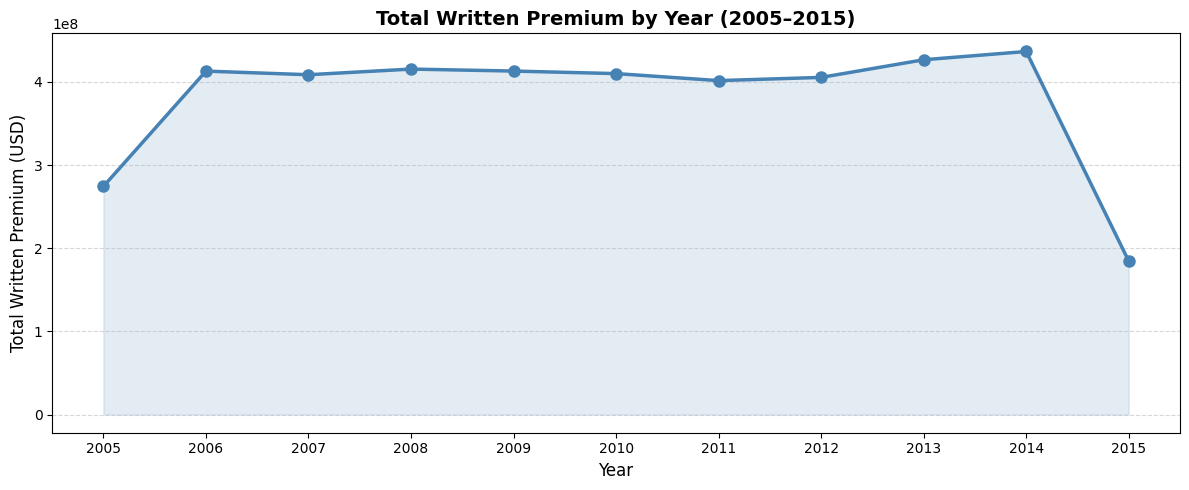

    Year  Total_Written_Premium
0   2005           274320178.95
1   2006           412880799.37
2   2007           408545579.01
3   2008           415328641.12
4   2009           412956224.14
5   2010           409893016.52
6   2011           401476307.87
7   2012           405323610.49
8   2013           426535472.01
9   2014           436479047.44
10  2015           184462286.60


In [7]:
# Aggregate total written premium by year
annual_premium = df.groupby('STAT_PROFILE_DATE_YEAR')['WRTN_PREM_AMT'].sum().reset_index()
annual_premium.columns = ['Year', 'Total_Written_Premium']

plt.figure(figsize=(12, 5))
plt.plot(annual_premium['Year'], annual_premium['Total_Written_Premium'], 
         marker='o', linewidth=2.5, color='steelblue', markersize=8)
plt.fill_between(annual_premium['Year'], annual_premium['Total_Written_Premium'], 
                 alpha=0.15, color='steelblue')
plt.title('Total Written Premium by Year (2005–2015)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Written Premium (USD)', fontsize=12)
plt.xticks(annual_premium['Year'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../reports/fig_5_1_annual_premium_trend.png', dpi=150)
plt.show()
print(annual_premium)

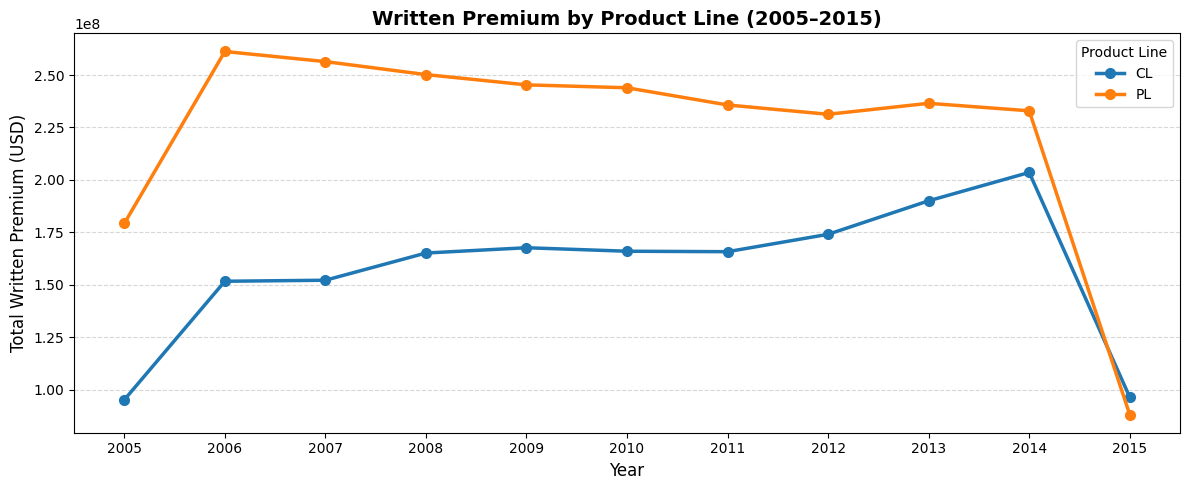

In [8]:
prod_premium = df.groupby(['STAT_PROFILE_DATE_YEAR', 'PROD_LINE'])['WRTN_PREM_AMT'].sum().reset_index()

plt.figure(figsize=(12, 5))
for line, group in prod_premium.groupby('PROD_LINE'):
    plt.plot(group['STAT_PROFILE_DATE_YEAR'], group['WRTN_PREM_AMT'],
             marker='o', linewidth=2.5, label=line, markersize=7)

plt.title('Written Premium by Product Line (2005–2015)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Written Premium (USD)', fontsize=12)
plt.legend(title='Product Line')
plt.xticks(annual_premium['Year'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../reports/fig_5_2_premium_by_product_line.png', dpi=150)
plt.show()

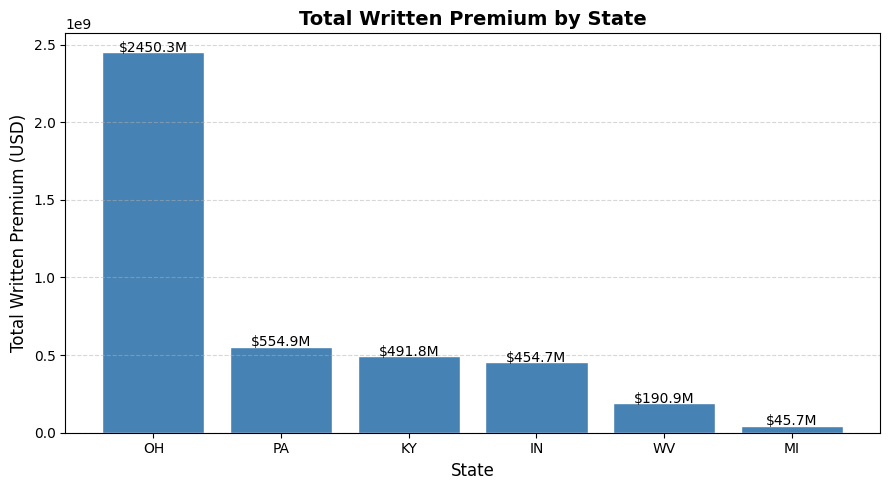

In [9]:
state_premium = df.groupby('STATE_ABBR')['WRTN_PREM_AMT'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(9, 5))
bars = plt.bar(state_premium['STATE_ABBR'], state_premium['WRTN_PREM_AMT'],
               color='steelblue', edgecolor='white')
plt.title('Total Written Premium by State', fontsize=14, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Total Written Premium (USD)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1e6,
             f'${bar.get_height()/1e6:.1f}M', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/fig_5_3_premium_by_state.png', dpi=150)
plt.show()

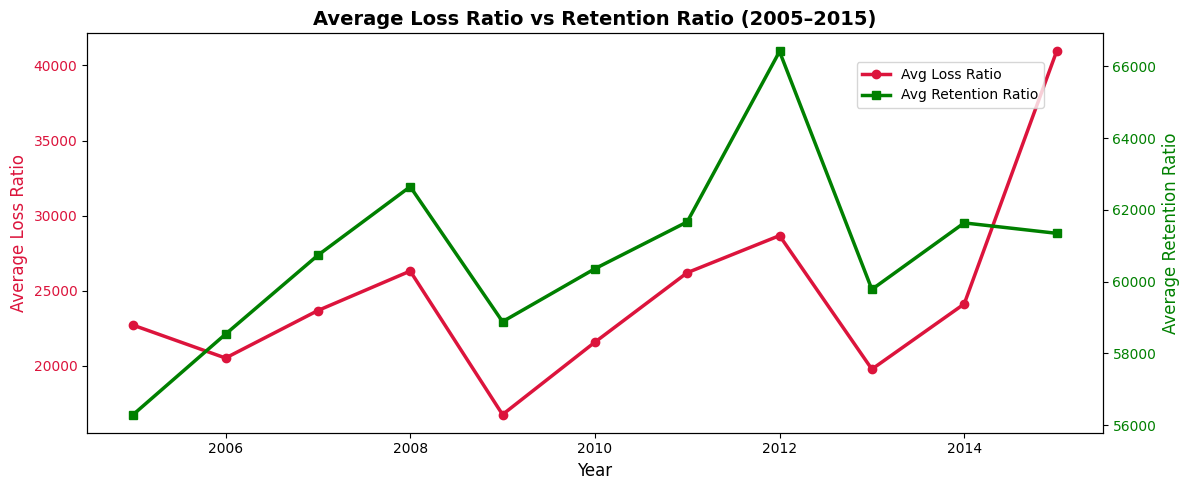

In [10]:
# Financial health indicators over time
financial = df.groupby('STAT_PROFILE_DATE_YEAR').agg(
    Avg_Loss_Ratio=('LOSS_RATIO', 'mean'),
    Avg_Retention_Ratio=('RETENTION_RATIO', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(financial['STAT_PROFILE_DATE_YEAR'], financial['Avg_Loss_Ratio'],
         color='crimson', marker='o', linewidth=2.5, label='Avg Loss Ratio')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Average Loss Ratio', color='crimson', fontsize=12)
ax1.tick_params(axis='y', labelcolor='crimson')

ax2 = ax1.twinx()
ax2.plot(financial['STAT_PROFILE_DATE_YEAR'], financial['Avg_Retention_Ratio'],
         color='green', marker='s', linewidth=2.5, label='Avg Retention Ratio')
ax2.set_ylabel('Average Retention Ratio', color='green', fontsize=12)
ax2.tick_params(axis='y', labelcolor='green')

plt.title('Average Loss Ratio vs Retention Ratio (2005–2015)', fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../reports/fig_5_4_loss_vs_retention.png', dpi=150)
plt.show()

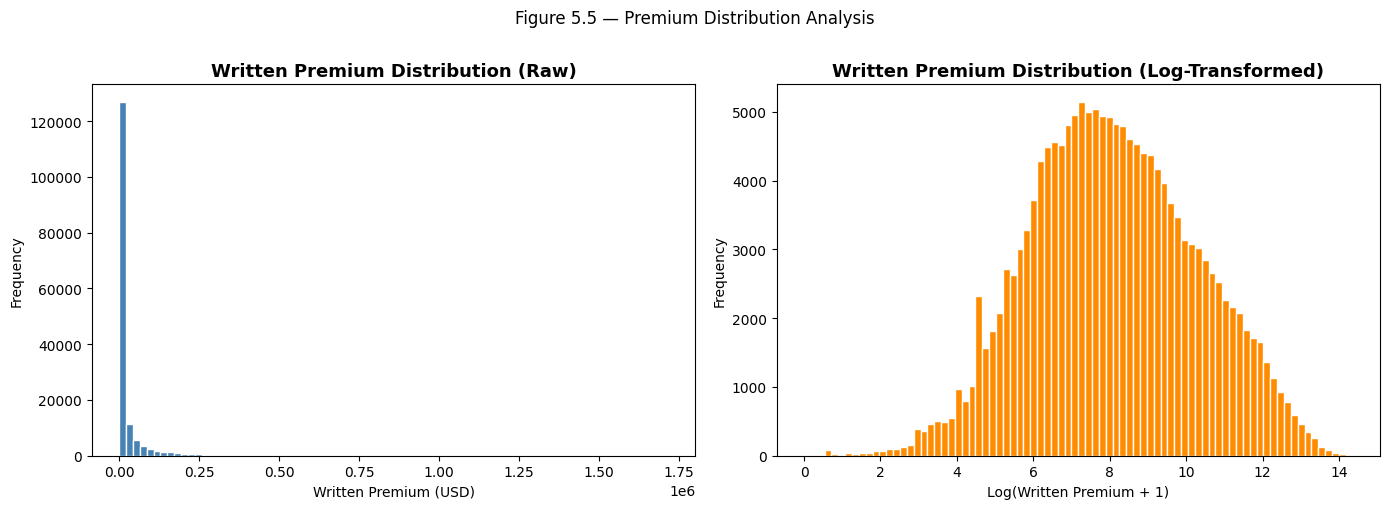

In [11]:
# Filter out negatives for distribution plot only
df_pos = df[df['WRTN_PREM_AMT'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df_pos['WRTN_PREM_AMT'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Written Premium Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Written Premium (USD)')
axes[0].set_ylabel('Frequency')

# Log-transformed distribution
axes[1].hist(np.log1p(df_pos['WRTN_PREM_AMT']), bins=80, color='darkorange', edgecolor='white')
axes[1].set_title('Written Premium Distribution (Log-Transformed)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Log(Written Premium + 1)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Figure 5.5 — Premium Distribution Analysis', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../reports/fig_5_5_premium_distribution.png', dpi=150)
plt.show()

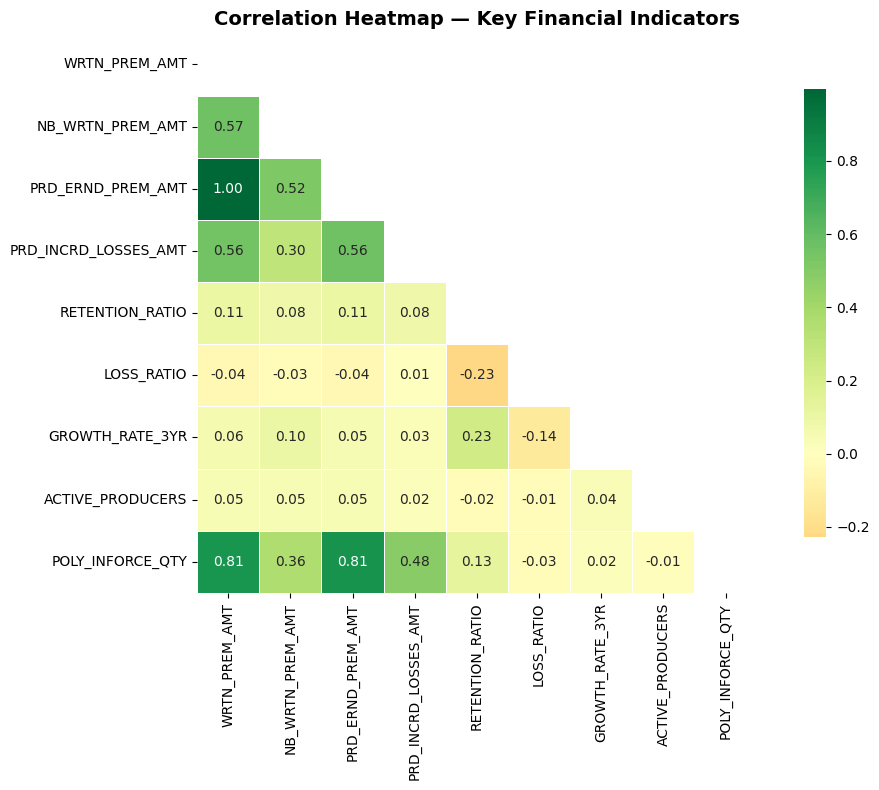

In [12]:
# Select key financial columns only
corr_cols = [
    'WRTN_PREM_AMT', 'NB_WRTN_PREM_AMT', 'PRD_ERND_PREM_AMT',
    'PRD_INCRD_LOSSES_AMT', 'RETENTION_RATIO', 'LOSS_RATIO',
    'GROWTH_RATE_3YR', 'ACTIVE_PRODUCERS', 'POLY_INFORCE_QTY'
]

# Replace 99999 sentinel values before correlation
df_corr = df[corr_cols].replace(99999, np.nan)

plt.figure(figsize=(11, 8))
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap — Key Financial Indicators', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_5_6_correlation_heatmap.png', dpi=150)
plt.show()